**DMV Practical No.-4**
                                         
                                        -By Aditya Nikam(BE AI & DS)

Data Wrangling
Problem Statement: Data Wrangling on Real Estate Market
Dataset: "RealEstate_Prices.csv"
Description: The dataset contains information about housing prices in a specific real estate
market. It includes various attributes such as property characteristics, location, sale prices,
and other relevant features. The goal is to perform data wrangling to gain insights into the
factors influencing housing prices and prepare the dataset for further analysis or modeling.
Tasks to Perform:
1. Import the "RealEstate_Prices.csv" dataset. Clean column names by removing spaces,
special characters, or renaming them for clarity.
2. Handle missing values in the dataset, deciding on an appropriate strategy (e.g.,
imputation or removal).
3. Perform data merging if additional datasets with relevant information are available
(e.g., neighborhood demographics or nearby amenities).
4. Filter and subset the data based on specific criteria, such as a particular time period,
property type, or location.
5. Handle categorical variables by encoding them appropriately (e.g., one-hot encoding or
label encoding) for further analysis.
6. Aggregate the data to calculate summary statistics or derived metrics such as average
sale prices by neighborhood or property type.
7. Identify and handle outliers or extreme values in the data that may affect the analysis
or modeling process

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("real_estate_bengaluru_house_prices_DMV Practical No-4.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
obj_cols = df.select_dtypes(include=['object']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[obj_cols] = df[obj_cols].fillna(df[obj_cols].mode().iloc[0])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   size          13320 non-null  object 
 4   society       13320 non-null  object 
 5   total_sqft    13320 non-null  object 
 6   bath          13320 non-null  float64
 7   balcony       13320 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [7]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [8]:
df['size'] = df['size'].str[0].astype(float)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   size          13320 non-null  float64
 4   society       13320 non-null  object 
 5   total_sqft    13320 non-null  object 
 6   bath          13320 non-null  float64
 7   balcony       13320 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(4), object(5)
memory usage: 936.7+ KB


In [10]:
df_ready = df[df['availability'] == 'Ready To Move']
print("Ready to Move properties:", df_ready.shape[0])

Ready to Move properties: 10581


In [11]:
df_dec = df[df['availability'].str.contains('Dec', case=False, na=False)]
print("Properties available in December:", df_dec.shape[0])

Properties available in December: 728


In [12]:
df_whitefield = df[df['location'] == 'Whitefield']
print("Properties in Whitefield:", df_whitefield.shape[0])

Properties in Whitefield: 541


In [13]:
df_3bhk = df[df['size'] == 3.0]
print("3 BHK properties:", df_3bhk.shape[0])

3 BHK properties: 4857


In [14]:
df_filtered = df[(df['size'] == 3.0) &
                 (df['availability'] == 'Ready To Move') &
                 (df['location'] == 'Whitefield')]
print("Filtered data shape:", df_filtered.shape[0])

Filtered data shape: 101


In [15]:
df.select_dtypes(include='object').columns

Index(['area_type', 'availability', 'location', 'society', 'total_sqft'], dtype='object')

In [16]:
df_encoded = df.copy()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['area_type', 'availability', 'location', 'size', 'society']:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


In [18]:
avg_price_location = df.groupby('location')['price'].mean().reset_index()
avg_price_location.columns = ['Location', 'Average_Price (in Lakhs)']#Naming the columns as Location and Average Price(in Lakhs)
avg_price_location = avg_price_location.sort_values(by='Average_Price (in Lakhs)', ascending=False)#Sorting
avg_price_location = avg_price_location.reset_index(drop=True)
avg_price_location.head(15)

,Location,Average_Price (in Lakhs)
0,Cubbon Road,1900.000000
1,Ashok Nagar,1486.000000
2,Defence Colony,1167.714286
3,Yemlur,1093.388889
4,Church Street,1068.000000
5,D Souza Layout,1015.000000
6,Sadashiva Nagar,1011.100000
7,Sindhi Colony,988.000000
8,Srinivas Colony,922.000000
9,5th Block Jayanagar,905.000000


In [19]:
avg_price_bhk = df.groupby('size')['price'].mean().reset_index()
avg_price_bhk.columns = ['BHK_Type', 'Average_Price (Lakhs)']
avg_price_bhk = avg_price_bhk.sort_values(by='Average_Price (Lakhs)', ascending=False).reset_index(drop=True)
avg_price_bhk

,BHK_Type,Average_Price (Lakhs)
0,5.0,281.549157
1,4.0,270.909062
2,7.0,244.370000
3,9.0,241.944444
4,6.0,223.927602
5,8.0,207.550562
6,3.0,110.952326
7,2.0,59.723468
8,1.0,58.043412


In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


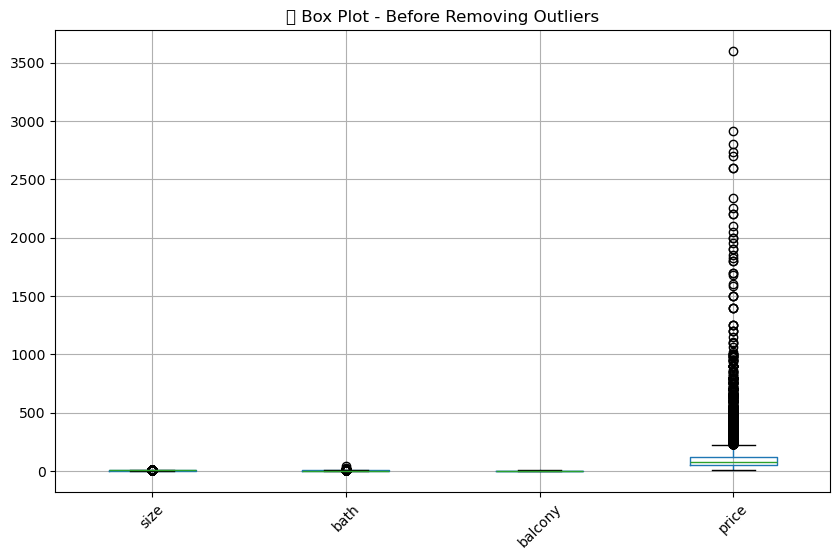

In [21]:
plt.figure(figsize=(10,6))
df[num_cols].boxplot()
plt.title("📊 Box Plot - Before Removing Outliers")
plt.xticks(rotation=45)
plt.show()

In [22]:
outliers={}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    outliers[col] = outlier_count


pd.DataFrame.from_dict(outliers, orient='index', columns=['Outlier Count'])

,Outlier Count
size,820
bath,1039
balcony,0
price,1276


In [23]:
df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


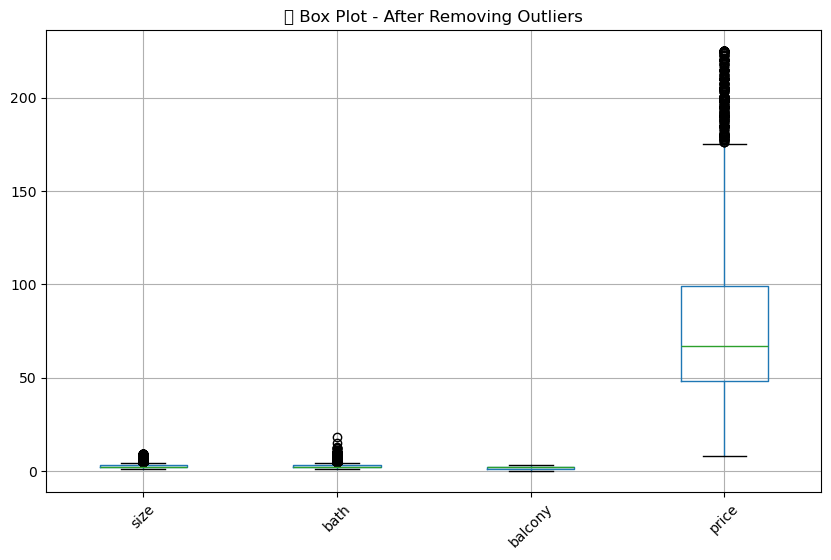

In [24]:

plt.figure(figsize=(10,6))
df[num_cols].boxplot()
plt.title("📊 Box Plot - After Removing Outliers")
plt.xticks(rotation=45)
plt.show()